# 🏠 Home Value Insights: Проект по линейной регрессии

**Описание:**  
Датасет для начинающих, чтобы практиковаться с прогнозированием цен на дома.  
Содержит 1000 домов с разными характеристиками.

---

## 📊 Признаки (Features)

| Признак | Описание |
|---------|----------|
| **Square_Footage** | Площадь дома в квадратных футах |
| **Num_Bedrooms** | Количество спален |
| **Num_Bathrooms** | Количество ванных комнат |
| **Year_Built** | Год постройки |
| **Lot_Size** | Размер участка в акрах |
| **Garage_Size** | Вместимость гаража (кол-во машин) |
| **Neighborhood_Quality** | Рейтинг района (1-10) |
| **House_Price** | **Целевая переменная** — цену дома, которую нужно предсказать |

---

## 🎯 Что можно делать

- Построить модель линейной регрессии для предсказания цены  
- Попробовать другие модели: Decision Tree, Random Forest  
- Сделать простой анализ данных (EDA)  
- Посчитать качество модели (R², MAE)  




In [7]:
import pandas as pd    #импортируем библиотеку pandas

In [10]:
# читаем файла с данными и сохраняем в df
df = pd.read_csv('house_price_regression_dataset.csv')

In [11]:
df.head(10) # получаем первые 10 строк таблицы df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
5,3944,5,3,1990,2.475930,2,8,8.797970e+05
6,3671,1,2,2012,4.911960,0,1,8.144279e+05
7,3419,1,1,1972,2.805281,1,1,7.034131e+05
8,630,3,3,1997,1.014286,1,8,1.738750e+05
9,2185,4,2,1981,3.941604,2,5,5.041765e+05


In [12]:
df.info()# получаем общую информацию о данных в таблице df

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB




<span style="color:red">Исправим стиль в заголовках столбцов, исключим пропуски. Затем проверим данные на дубликаты</span>

In [16]:
df.columns # вводим перечень названий столбцов таблицы df

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='str')

In [24]:
# переименовываем столбцы в соответствие с хорошим стилем
df = df.rename(columns = {'Square_Footage':'area','Num_Bedrooms':'bedrooms','Num_Bathrooms': 'bathrooms', 'Year_Built': 'year',
       'Lot_Size': 'lotarea', 'Garage_Size': 'garage', 'Neighborhood_Quality':'neighborhood', 'House_Price': 'price'})

In [29]:
df.columns # проверяем результат - перечень названий столбцов

Index(['area', 'bedrooms', 'bathrooms', 'year', 'lotarea', 'garage',
       'neighborhood', 'price'],
      dtype='str')

## Пропуски значений


In [30]:
df.isna().sum()# подсчитываем пропуски

area            0
bedrooms        0
bathrooms       0
year            0
lotarea         0
garage          0
neighborhood    0
price           0
dtype: int64

## Дубликаты

In [33]:
df.duplicated().sum() # подсчитываем явные дубликаты

np.int64(0)

## Выводы
Названия столбцов были приведены к единому стилю, что упрощает работу с данными. Проверка на дубликаты и пропуски показала, что таких значений нет.

In [34]:
import matplotlib.pyplot as plt #импортируем библиотеку matplotlib

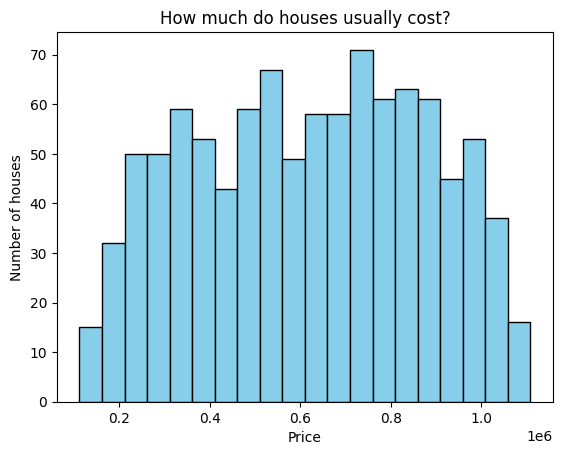

In [36]:
# Нарисуем гистограмму цен домов
plt.hist(df['price'], bins = 20, color='skyblue', edgecolor='black')
plt.title('How much do houses usually cost?')
plt.xlabel('Price')
plt.ylabel('Number of houses')
plt.show()

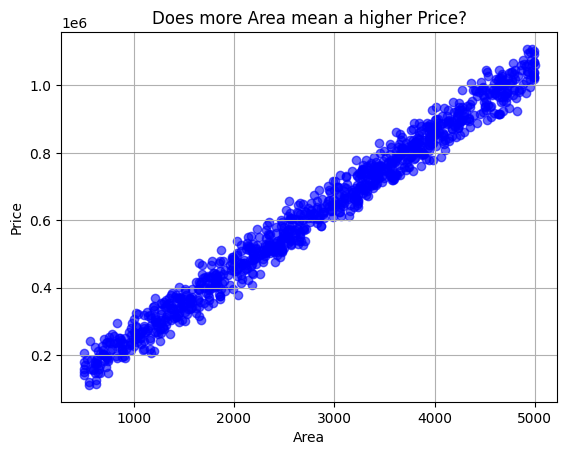

In [37]:
# Точечная диаграмма: площадь домов vs цена
plt.scatter(df['area'], df['price'], color = 'blue', alpha = 0.6)
plt.title('Does more Area mean a higher Price?')
plt.xlabel('Area')
plt.ylabel('Price')
plt.grid(True)  # добавим сетку для удобства
plt.show()

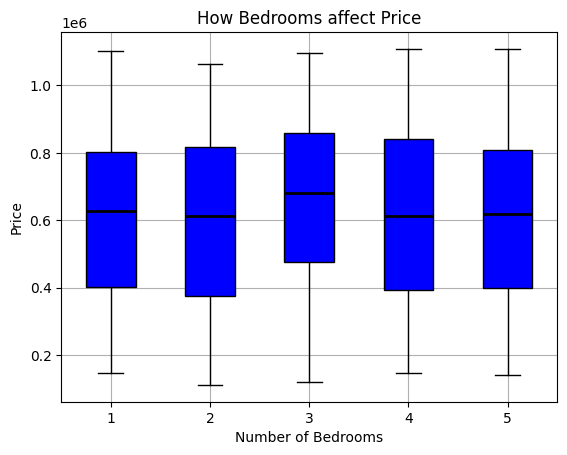

In [42]:
# Строим коробчатую диаграмму (boxplot) для каждого количества спален,
plt.boxplot([df[df['bedrooms']==b]['price'] for b in sorted(df['bedrooms'].unique())],
            tick_labels=sorted(df['bedrooms'].unique()),
            patch_artist=True,
            boxprops=dict(facecolor='blue'),  # цвет самой коробки
            medianprops=dict(color='black', linewidth=2))  # цвет и толщина медианы)
plt.title('How Bedrooms affect Price')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.grid(True)
plt.show()

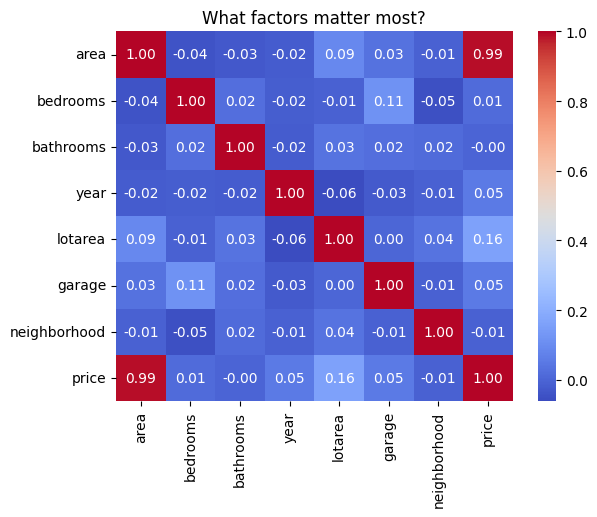

In [47]:
# Нарисуем матрицу корреляции
import seaborn as sns # импортируем библиотеку seaborn

# Корреляция только по числовым столбцам
correlation_matrix = df.corr(numeric_only=True)

# Строим тепловую карту с цифрами на клетках
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('What factors matter most?')
plt.show()

In [48]:
x = df.drop('price', axis =1)
y = df['price']

In [49]:
# Строим и обучаем модели машинного обучения, чтобы предсказывать цену дома на основе признаков
# импортируем библиотеку sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Создаём модель
model = LinearRegression()
model.fit(x_train, y_train) 

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [50]:
y_pred = model.predict(x_test)    

In [52]:
from sklearn import metrics
import numpy as np
# Metrics Calculation
print('1. Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred)) # indicates ---> average error
print('2. Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, y_pred)) # indicates -----> squared error
print('3. Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('4. R2 Score (Accuracy):', metrics.r2_score(y_test, y_pred)) # indicates ----> best score

1. Mean Absolute Error (MAE): 8174.583600008741
2. Mean Squared Error (MSE): 101434798.50566845
3. Root Mean Squared Error (RMSE): 10071.4844241387
4. R2 Score (Accuracy): 0.9984263636823408


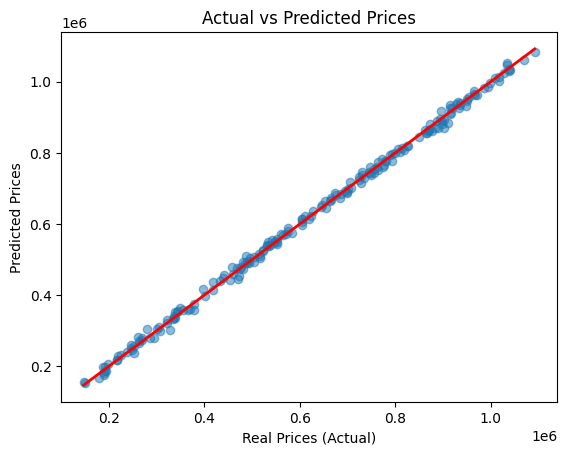

In [55]:
# На графике показано, как предсказанные моделью цены домов (ось Y) 
# соотносятся с реальными ценами (ось X).
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)  # линия y=x
plt.xlabel('Real Prices (Actual)')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()


## ИТОГ
Моя модель неплохо угадывает цены домов, если смотреть на площадь и количество комнат.
Линейная регрессия помогла понять, как эти вещи влияют на цену.
Минусы: модель не знает про вид из окна, близость к парку или новую кухню.
В целом, предсказания точные (R² ≈ 0.998), но есть мелкие моменты, которые она не учитывает.